Section 1: Loading simulation files and performing 80/20 train/test split...
Section 2: Transforming windows and applying feature-type normalization...

Training Official Hopfield Layer on Mini-Batches: 1-Frame Window
 > Epoch 001 | Average Reconstruct MSE Loss: 0.814792
 > Epoch 010 | Average Reconstruct MSE Loss: 0.762745
 > Epoch 020 | Average Reconstruct MSE Loss: 0.760779
 > Epoch 030 | Average Reconstruct MSE Loss: 0.764658
 > Epoch 040 | Average Reconstruct MSE Loss: 0.750055
 > Epoch 050 | Average Reconstruct MSE Loss: 0.748236
 > Epoch 060 | Average Reconstruct MSE Loss: 0.743872
 > Epoch 070 | Average Reconstruct MSE Loss: 0.748960
 > Epoch 080 | Average Reconstruct MSE Loss: 0.749000
 > Epoch 090 | Average Reconstruct MSE Loss: 0.754784
 > Epoch 100 | Average Reconstruct MSE Loss: 0.748412
 > Epoch 110 | Average Reconstruct MSE Loss: 0.746086
 > Epoch 120 | Average Reconstruct MSE Loss: 0.751019
 > Epoch 130 | Average Reconstruct MSE Loss: 0.751442
 > Epoch 140 | Average Rec

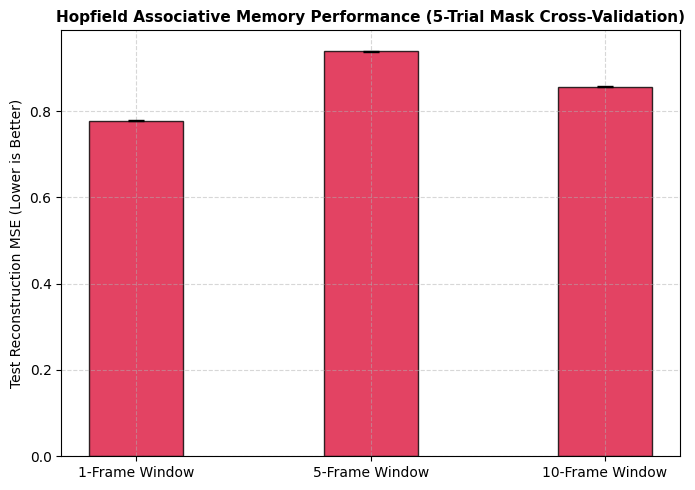

In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from hflayers import HopfieldLayer

# Enforce strict scientific reproducibility across all components
torch.manual_seed(42)
np.random.seed(42)

# Global Settings
data_dir = "simulation_data"
num_cells = 20
cell_features = 5
num_attractors = 8  
num_epochs = 150
num_files = 50
batch_size = 128    # Mini-batch training scale
num_trials = 5      # Number of random evaluation masks per representation

representations = {
    "1-Frame Window":  {"size": 1,   "dim": 1 * num_cells * cell_features},
    "5-Frame Window":  {"size": 5,   "dim": 5 * num_cells * cell_features},
    "10-Frame Window": {"size": 10,  "dim": 10 * num_cells * cell_features}
}

# ==========================================
# SECTION 1: DATASET LOADING WITH TRAIN/TEST SPLIT
# ==========================================
print("Section 1: Loading simulation files and performing 80/20 train/test split...")
train_num = 40

train_killing_files = [np.load(os.path.join(data_dir, f"data_killing_{i}.npy")) for i in range(train_num)]
test_killing_files = [np.load(os.path.join(data_dir, f"data_killing_{i}.npy")) for i in range(train_num, num_files)]

train_non_killing_files = [np.load(os.path.join(data_dir, f"data_non-killing_{i}.npy")) for i in range(train_num)]
test_non_killing_files = [np.load(os.path.join(data_dir, f"data_non-killing_{i}.npy")) for i in range(train_num, num_files)]

# ==========================================
# SECTION 2: REPRESENTATION GENERATION & PER-FEATURE NORMALIZATION
# ==========================================
print("Section 2: Transforming windows and applying feature-type normalization...")

def slice_trajectories(file_list, window_size):
    structured_data = []
    for matrix in file_list:
        t_matrix = matrix.transpose(1, 0, 2)  # Shape: (time, cells, features)
        timesteps = t_matrix.shape[0]
        windows = []
        for t in range(timesteps - window_size + 1):
            windows.append(t_matrix[t:t+window_size].flatten())
        structured_data.append(np.array(windows))
    return structured_data

results = {}
for name, config in representations.items():
    w_size = config["size"]
    v_dim = config["dim"]
    
    tr_k_sliced = slice_trajectories(train_killing_files, w_size)
    tr_nk_sliced = slice_trajectories(train_non_killing_files, w_size)
    te_k_sliced = slice_trajectories(test_killing_files, w_size)
    te_nk_sliced = slice_trajectories(test_non_killing_files, w_size)
    
    global_train_flat = np.concatenate(tr_k_sliced + tr_nk_sliced, axis=0)
    reshaped_features = global_train_flat.reshape(-1, cell_features)
    f_mean = np.mean(reshaped_features, axis=0)
    f_std = np.std(reshaped_features, axis=0) + 1e-6
    
    def normalize_set(sliced_list):
        normed = []
        for item in sliced_list:
            rescaled = item.reshape(-1, cell_features)
            normed_feat = (rescaled - f_mean) / f_std
            normed.append(normed_feat.reshape(item.shape))
        return normed

    results[name] = {
        "v_dim": v_dim,
        "w_size": w_size,
        "train_k": normalize_set(tr_k_sliced),
        "train_nk": normalize_set(tr_nk_sliced),
        "test_k": normalize_set(te_k_sliced),
        "test_nk": normalize_set(te_nk_sliced)
    }

# ==========================================
# SECTION 3: UNSUPERVISED HOPFIELD LAYER MINI-BATCH TRAINING
# ==========================================
def apply_biological_mask(tensor_batch, w_size, num_cells=20):
    """
    Handles strided indexing for row-major flattened vectors.
    Masks out 4 randomly selected biological cells across ALL frames in the window.
    """
    corrupted = tensor_batch.clone()
    b_size = corrupted.shape[0]
    frame_stride = num_cells * cell_features 
    
    for b in range(b_size):
        dropped_cells = np.random.choice(num_cells, size=4, replace=False)
        for cell in dropped_cells:
            for f in range(w_size):
                start_idx = (f * frame_stride) + (cell * cell_features)
                end_idx = start_idx + cell_features
                corrupted[b, 0, start_idx:end_idx] = 0.0
    return corrupted

for name, res in results.items():
    print(f"\nTraining Official Hopfield Layer on Mini-Batches: {name}")
    v_dim = res["v_dim"]
    
    flat_train_data = np.concatenate(res["train_k"] + res["train_nk"], axis=0)
    X_train_tensor = torch.tensor(flat_train_data, dtype=torch.float32).unsqueeze(1) # [N, 1, v_dim]
    
    train_dataset = TensorDataset(X_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    chnn = HopfieldLayer(
        input_size=v_dim,
        quantity=num_attractors,
        stored_pattern_as_static=False,
        state_pattern_as_static=True,
        scaling=30.0
    )
    
    optimizer = optim.Adam(chnn.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    
    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0
        for batch in train_loader:
            X_batch = batch[0]
            optimizer.zero_grad()
            X_masked = apply_biological_mask(X_batch, w_size=res["w_size"])
            reconstructed = chnn(X_masked)
            loss = criterion(reconstructed, X_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
            
        if epoch == 1 or epoch % 10 == 0:
            print(f" > Epoch {epoch:03d} | Average Reconstruct MSE Loss: {epoch_loss / len(train_dataset):.6f}")
        
    res["model"] = chnn

# ==========================================
# SECTION 4: EVALUATION (MULTI-TRIAL MC TESTING VARIANCE)
# ==========================================
print("\nSection 4: Evaluating denoising reconstruction error over multiple randomized trials...")

for name, res in results.items():
    chnn = res["model"]
    chnn.eval()
    criterion = nn.MSELoss()
    
    X_test = torch.tensor(np.concatenate(res["test_k"] + res["test_nk"], axis=0), dtype=torch.float32).unsqueeze(1)
    
    mse_list = []
    with torch.no_grad():
        for _ in range(num_trials):
            X_test_masked = apply_biological_mask(X_test, w_size=res["w_size"])
            X_eval_recovered = chnn(X_test_masked)
            mse_list.append(criterion(X_eval_recovered, X_test).item())
            
    res["recon_mse_mean"] = np.mean(mse_list)
    res["recon_mse_std"] = np.std(mse_list)

# ==========================================
# SECTION 5: VISUALIZATION & OUTPUT
# ==========================================
print("\nSection 5: Rendering benchmarking summary and saving output plots...")

print("\n" + "="*65)
print(f"{'Representation':<25} | {'Test Reconstruction MSE (Mean ± Std)':<35}")
print("="*65)
for name, res in results.items():
    print(f"{name:<25} | {res['recon_mse_mean']:<.5f} ± {res['recon_mse_std']:<.5f}")
print("="*65)

# Generate single bar chart mapping Test Reconstruction MSE alongside confidence intervals
labels = list(representations.keys())
means = [results[name]["recon_mse_mean"] for name in labels]
stds = [results[name]["recon_mse_std"] for name in labels]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, means, yerr=stds, color='crimson', alpha=0.8, edgecolor='black', width=0.4, capsize=6, error_kw={'ecolor': 'black', 'elinewidth': 1.5})
ax.set_title("Hopfield Associative Memory Performance (5-Trial Mask Cross-Validation)", fontsize=11, fontweight='bold')
ax.set_ylabel("Test Reconstruction MSE (Lower is Better)", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("representation_comparison.png", dpi=300)
print("\nStatistical variance evaluation complete. Visualization saved with error bars.")

\begin{aligned}
&\text{\#Optimized Version} \\
&\text{Changed batch size to 120} \\
&\text{Removed Normalisation step}
\end{aligned}


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from hflayers import HopfieldLayer

# Enforce strict scientific reproducibility across all components
torch.manual_seed(42)
np.random.seed(42)

# Global Settings
data_dir = "simulation_data"
training_files_count = 40 #40 *2 = 80 files for training, 20 for testing
testing_files_count = 10  #10 *2 = 20 files for testing
num_cells = 20
cell_features = 5
num_attractors = 8  
num_epochs = 150
num_files = 50
batch_size = 120    # Mini-batch training scale, changed the batch size to 120 
                        #to make ensure two files dont fall in the same window
num_trials = 5      # Number of random evaluation masks per representation

representations = {
    "1-Frame Window":  {"size": 1,   "dim": 1 * num_cells * cell_features},
    "5-Frame Window":  {"size": 5,   "dim": 5 * num_cells * cell_features},
    "10-Frame Window": {"size": 10,  "dim": 10 * num_cells * cell_features}
}

# ==========================================
# SECTION 1: DATASET LOADING WITH TRAIN/TEST SPLIT
# ==========================================
print("Section 1: Loading simulation files and performing 80/20 train/test split...")
train_num = training_files_count

train_killing_files = [np.load(os.path.join(data_dir, f"data_killing_{i}.npy")) for i in range(train_num)]
test_killing_files = [np.load(os.path.join(data_dir, f"data_killing_{i}.npy")) for i in range(train_num, num_files)]

train_non_killing_files = [np.load(os.path.join(data_dir, f"data_non-killing_{i}.npy")) for i in range(train_num)]
test_non_killing_files = [np.load(os.path.join(data_dir, f"data_non-killing_{i}.npy")) for i in range(train_num, num_files)]

# ==========================================
# SECTION 2: REPRESENTATION GENERATION & PER-FEATURE NORMALIZATION
# ==========================================
print("Section 2: Transforming windows and applying feature-type normalization...")

def slice_trajectories(file_list, window_size):
    structured_data = []
    for matrix in file_list:
        t_matrix = matrix.transpose(1, 0, 2)  # Shape: (time, cells, features)
        timesteps = t_matrix.shape[0]
        windows = []
        for t in range(timesteps - window_size + 1):
            windows.append(t_matrix[t:t+window_size].flatten())
        structured_data.append(np.array(windows))
    return structured_data

results = {}
for name, config in representations.items():
    w_size = config["size"]
    v_dim = config["dim"]
    
    tr_k_sliced = slice_trajectories(train_killing_files, w_size)
    tr_nk_sliced = slice_trajectories(train_non_killing_files, w_size)
    te_k_sliced = slice_trajectories(test_killing_files, w_size)
    te_nk_sliced = slice_trajectories(test_non_killing_files, w_size)
    
    results[name] = {
        "v_dim": v_dim,
        "w_size": w_size,
        "train_k": tr_k_sliced,
        "train_nk": tr_nk_sliced,
        "test_k": te_k_sliced,
        "test_nk": te_nk_sliced
    }

# ==========================================
# SECTION 3: UNSUPERVISED HOPFIELD LAYER MINI-BATCH TRAINING
# ==========================================
def apply_biological_mask(tensor_batch, w_size, num_cells=20):
    """
    Handles strided indexing for row-major flattened vectors.
    Masks out 4 randomly selected biological cells across ALL frames in the window.
    """
    corrupted = tensor_batch.clone()
    b_size = corrupted.shape[0]
    frame_stride = num_cells * cell_features 
    
    for b in range(b_size):
        dropped_cells = np.random.choice(num_cells, size=4, replace=False)
        for cell in dropped_cells:
            for f in range(w_size):
                start_idx = (f * frame_stride) + (cell * cell_features)
                end_idx = start_idx + cell_features
                corrupted[b, 0, start_idx:end_idx] = 0.0
    return corrupted

for name, res in results.items():
    print(f"\nTraining Official Hopfield Layer on Mini-Batches: {name}")
    v_dim = res["v_dim"]
    
    flat_train_data = np.concatenate(res["train_k"] + res["train_nk"], axis=0)
    X_train_tensor = torch.tensor(flat_train_data, dtype=torch.float32).unsqueeze(1) # [N, 1, v_dim]
    
    train_dataset = TensorDataset(X_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    chnn = HopfieldLayer(
        input_size=v_dim,
        quantity=num_attractors,
        stored_pattern_as_static=False,
        state_pattern_as_static=True,
        scaling=30.0
    )
    
    optimizer = optim.Adam(chnn.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    
    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0
        for batch in train_loader:
            X_batch = batch[0]
            optimizer.zero_grad()
            X_masked = apply_biological_mask(X_batch, w_size=res["w_size"])
            reconstructed = chnn(X_masked)
            loss = criterion(reconstructed, X_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
            
        if epoch == 1 or epoch % 10 == 0:
            print(f" > Epoch {epoch:03d} | Average Reconstruct MSE Loss: {epoch_loss / len(train_dataset):.6f}")
        
    res["model"] = chnn

# ==========================================
# SECTION 4: EVALUATION (MULTI-TRIAL MC TESTING VARIANCE)
# ==========================================
print("\nSection 4: Evaluating denoising reconstruction error over multiple randomized trials...")

for name, res in results.items():
    chnn = res["model"]
    chnn.eval()
    criterion = nn.MSELoss()
    
    X_test = torch.tensor(np.concatenate(res["test_k"] + res["test_nk"], axis=0), dtype=torch.float32).unsqueeze(1)
    
    mse_list = []
    with torch.no_grad():
        for _ in range(num_trials):
            X_test_masked = apply_biological_mask(X_test, w_size=res["w_size"])
            X_eval_recovered = chnn(X_test_masked)
            mse_list.append(criterion(X_eval_recovered, X_test).item())
            
    res["recon_mse_mean"] = np.mean(mse_list)
    res["recon_mse_std"] = np.std(mse_list)

# ==========================================
# SECTION 5: VISUALIZATION & OUTPUT
# ==========================================
print("\nSection 5: Rendering benchmarking summary and saving output plots...")

print("\n" + "="*65)
print(f"{'Representation':<25} | {'Test Reconstruction MSE (Mean ± Std)':<35}")
print("="*65)
for name, res in results.items():
    print(f"{name:<25} | {res['recon_mse_mean']:<.5f} ± {res['recon_mse_std']:<.5f}")
print("="*65)

# Generate single bar chart mapping Test Reconstruction MSE alongside confidence intervals
labels = list(representations.keys())
means = [results[name]["recon_mse_mean"] for name in labels]
stds = [results[name]["recon_mse_std"] for name in labels]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, means, yerr=stds, color='crimson', alpha=0.8, edgecolor='black', width=0.4, capsize=6, error_kw={'ecolor': 'black', 'elinewidth': 1.5})
ax.set_title("Hopfield Associative Memory Performance (5-Trial Mask Cross-Validation)", fontsize=11, fontweight='bold')
ax.set_ylabel("Test Reconstruction MSE (Lower is Better)", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("representation_comparison.png", dpi=300)
print("\nStatistical variance evaluation complete. Visualization saved with error bars.")

Section 1: Loading simulation files and performing 80/20 train/test split...
Section 2: Transforming windows and applying feature-type normalization...


KeyboardInterrupt: 